In [1]:
import pandas as pd
import pickle as pkl
import os
import numpy as np

In [2]:
res_dir = "./experiment/inference/IDH1_DDR_Glioma_test/"
name = "cross_cancer_all_no1_reactome"

In [20]:
## alpha11, alpha22, alpha12, alpha21
with open(os.path.join(res_dir, f"{name}_crossatt.pkl"), 'rb') as f: 
    cross_att_all = pkl.load(f)

## att1, att2
with open(os.path.join(res_dir, f"{name}_transformeratt.pkl"), 'rb') as f: 
    trans_att_all = pkl.load(f)

In [6]:
print(len(cross_att_all))
print(len(cross_att_all[0]))
print(cross_att_all[0][0].shape)

print(len(trans_att_all))
print(len(trans_att_all[0]))
print(trans_att_all[0][0].shape)

8
4
(181, 2, 60, 60)
8
2
(181, 2, 60, 60)


In [7]:
rank_res = pd.read_csv(os.path.join(res_dir, f"{name}.csv"), index_col=0)
rank_res.head()

,partner_gene,score
index,,
43,EXO1,0.182816
16,BRIP1,0.154578
39,EME1,0.143737
25,COPS3,0.133327
152,TIMELESS,0.126887


In [8]:
rank_res[rank_res["partner_gene"]=="PRKDC"].index.item()

112

attention vector

In [3]:
# Let's adjust the broadcasting to handle the matrix dimensions correctly during normalization
def att_score(A):
    """
    Process an attention matrix A according to the described steps.
    
    Args:
    A (numpy.ndarray): Input matrix of shape (no_layers * no_heads, L, L).
    
    Returns:
    numpy.ndarray: The final attention vector of length L.
    """
    
    # Step 1: Make the matrix symmetric by adding its transpose
    A_symmetric = A + A.transpose(0, 2, 1)
    
    # Step 2: Normalize the symmetric matrix
    sum_i = np.sum(A_symmetric, axis=1)  # Sum across rows
    sum_j = np.sum(A_symmetric, axis=2)  # Sum across columns
    sum_total = np.sum(A_symmetric)  # Sum of all elements
    
    # Compute the average value broadcast across elements
    avg_value = (sum_i[:, :, None] @ sum_j[:, None, :]) / sum_total  # Reshaping for broadcasting
    A_normalized = A_symmetric - avg_value  # Element-wise subtraction
    
    # Step 3: Sum along the no_layers * no_heads dimension
    A_reduced = np.sum(A_normalized, axis=0)
    
    # Step 4: Sum along the rows to generate the final attention vector
    attention_vector = np.sum(A_reduced, axis=0)
    
    return attention_vector


In [4]:
def get_gene_att_score(g, data_name):

    res_dir = "./experiment/inference/IDH1_DDR_Glioma_test/"
    
    with open(os.path.join(res_dir, f"{data_name}_crossatt.pkl"), 'rb') as f: 
        cross_att_all = pkl.load(f)
    with open(os.path.join(res_dir, f"{data_name}_transformeratt.pkl"), 'rb') as f: 
        trans_att_all = pkl.load(f)
    
    rank_res = pd.read_csv(os.path.join(res_dir, f"{data_name}.csv"), index_col=0)
    g_idx = rank_res[rank_res["partner_gene"]==g].index.item()

    cross_att_vec = [[],[],[],[]]
    for fold in range(len(cross_att_all)):
        for att_part in range(4):
            att = cross_att_all[fold][att_part][g_idx,:].squeeze()
            cross_att_vec[att_part].append(att_score(att))
    
    trans_att_vec = [[],[]]
    for fold in range(len(trans_att_all)):
        for att_part in range(2):
            att = trans_att_all[fold][att_part][g_idx,:].squeeze()
            trans_att_vec[att_part].append(att_score(att))

    cross_att_avg = []
    trans_att_avg = []
    for att_vec_allfold in cross_att_vec:
        cross_att_avg.append(np.mean(att_vec_allfold, axis=0))
    for att_vec_allfold in trans_att_vec:
        trans_att_avg.append(np.mean(att_vec_allfold, axis=0))

    return cross_att_avg, trans_att_avg

In [5]:
cross_att_IDH1_PRKDC, trans_att_IDH1_PRKDC = get_gene_att_score(g="PRKDC", data_name="cross_cancer_all_no1_reactome")

In [30]:
print(cross_att_IDH1_PRKDC[0].shape)
print(trans_att_IDH1_PRKDC[0].shape)

(60,)
(60,)


gene sentence idx

In [6]:
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2sent_n200_notransform.pkl", 'rb') as f: 
    gene2sent_map = pkl.load(f)
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2id.pkl", 'rb') as f: 
    gene2id_map = pkl.load(f)

id2gene_map = {i:g for g,i in gene2id_map.items()}
id2gene_map[-1]="pad"

In [7]:
def get_gene_sent(g_name, cancer=8, n=60):

    g_id = gene2id_map[g_name]
    ## Glioma cancer idx = 8
    g_sent_idx = gene2sent_map[cancer][g_id]
    g_sent = [id2gene_map[g-1] for g in g_sent_idx][:n]

    return g_sent


In [8]:
gene_sent_PRKDC = get_gene_sent("PRKDC")
print(gene_sent_PRKDC[:5])
gene_sent_IDH1 = get_gene_sent("IDH1")
print(gene_sent_IDH1[:5])

['PRKDC', 'LIMA1', 'IGFBP2', 'TRAF4', 'PTN']
['IDH1', 'FABP7', 'FABP5', 'RBP1', 'PTN']


Plot att heatmap

In [9]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [15]:
def plot_att_vec(vec):

    if vec.shape[0] == 4:
        y_tick = ["att11", "att22", "att12", "att21"]
    elif vec.shape[0] == 2:
        y_tick = ["att1", "att2"]

    plt.rcParams.update({'font.size': 8})
    fig_width = 6 if vec.shape[0]==4 else 3
    fig, axs = plt.subplots(vec.shape[0], 1, figsize = (15, fig_width))
    fig.set_dpi(300)
    fig.tight_layout(pad=3.0)

    for i in range(vec.shape[0]):
        if  i==0 or i==3:
            x_tick = gene_sent_IDH1
        elif i==1 or i==2:
            x_tick = gene_sent_PRKDC

        sns.heatmap(vec[i,:].reshape(1,-1), ax=axs[i], square=True, cmap="OrRd", cbar=False, xticklabels=x_tick)
        norm_unsoftmax = mpl.colors.Normalize(vmin = np.min(vec),
                                            vmax = np.max(vec))
        cbar_unsoftmax = fig.colorbar(mpl.cm.ScalarMappable(norm = norm_unsoftmax, cmap="OrRd"),
                                    orientation = 'vertical', ax = axs[i])
        cbar_unsoftmax.outline.set_visible(False)

        axs[i].set_xticklabels(x_tick, rotation=45)
        axs[i].set_ylabel(y_tick[i])

    if vec.shape[0] == 4:   
        fig.suptitle("cross attention scores")
    elif vec.shape[0] == 2:   
        fig.suptitle("transformer attention scores")


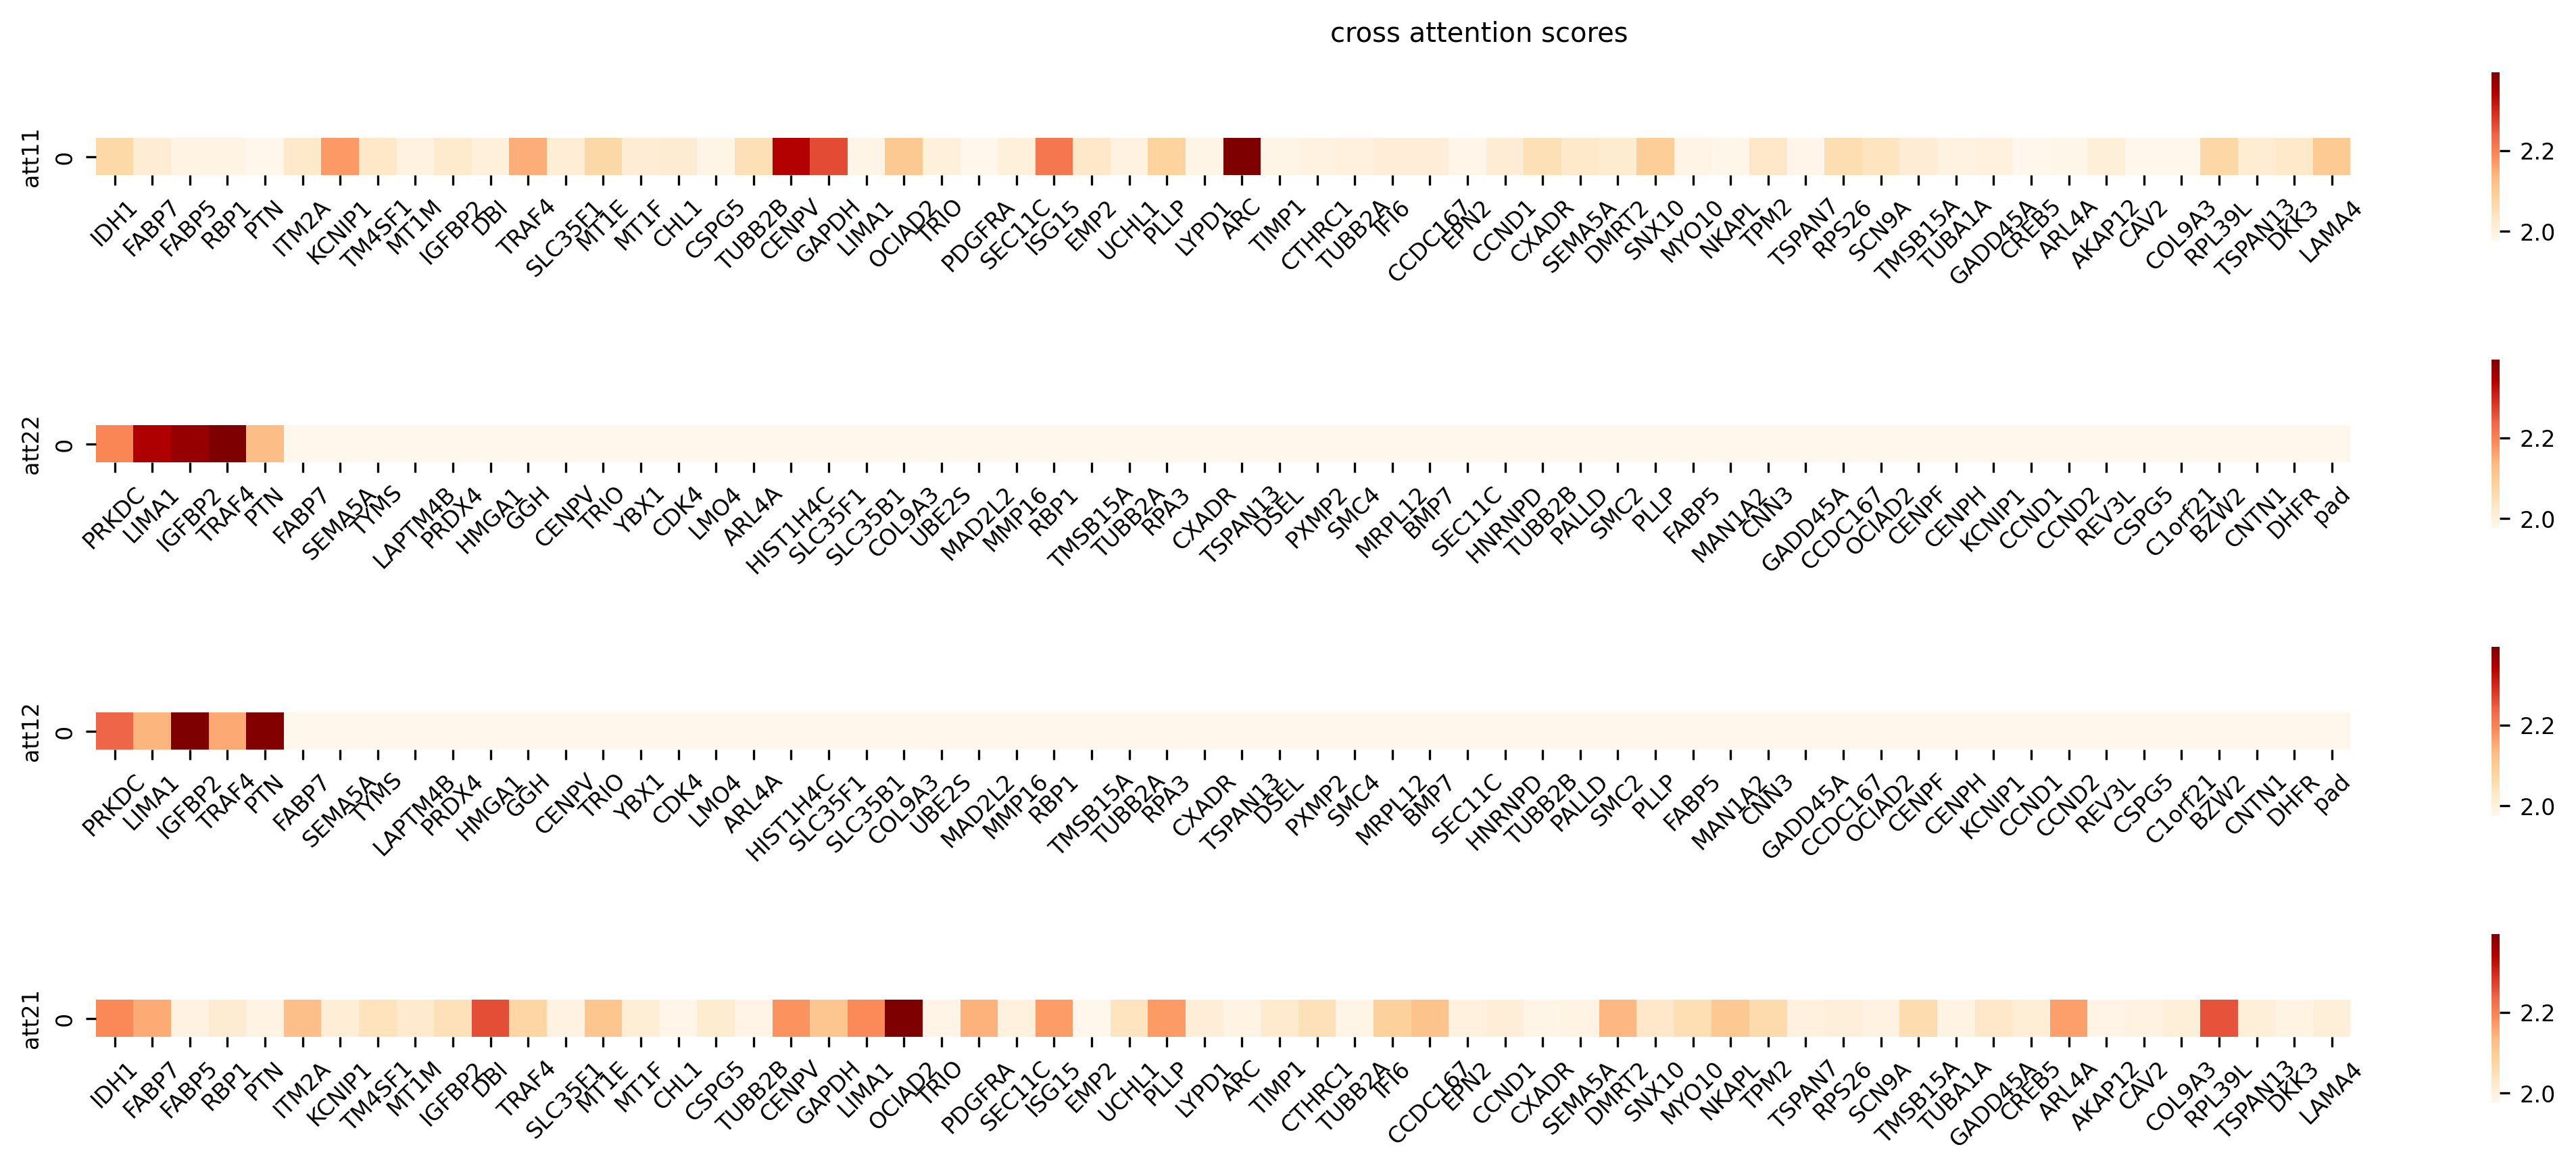

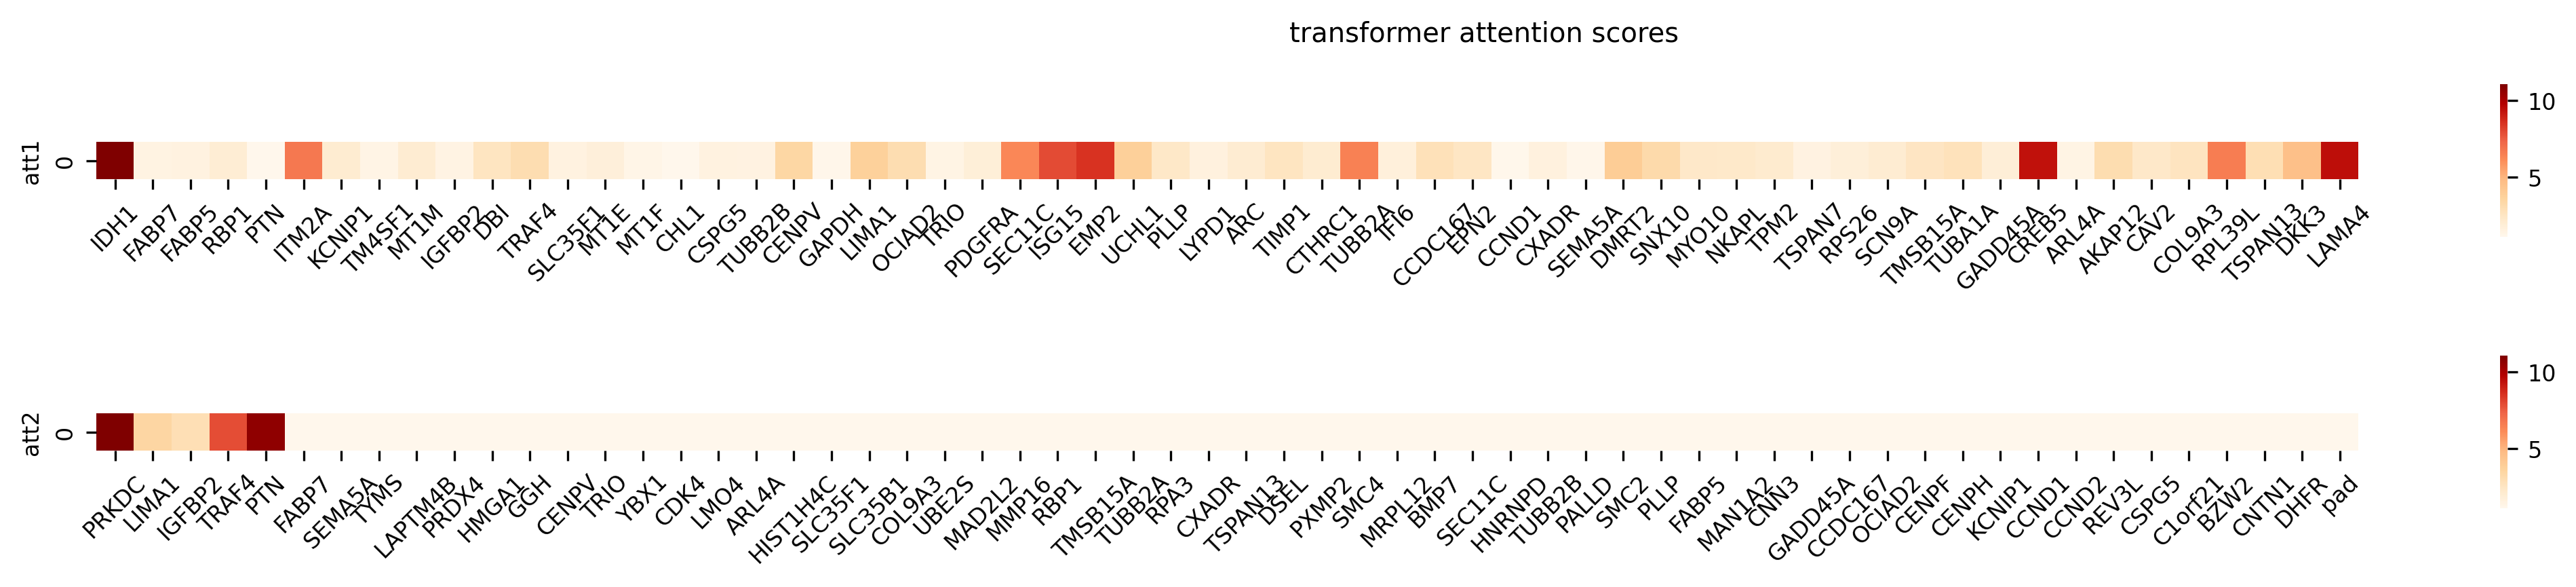

In [37]:
# vec = att_PRKDC[0].reshape(1,-1)

plot_att_vec(np.vstack(cross_att_IDH1_PRKDC))
plot_att_vec(np.vstack(trans_att_IDH1_PRKDC))


### average across models

In [1]:
import pandas as pd
import pickle as pkl
import os
import numpy as np

In [67]:
# Let's adjust the broadcasting to handle the matrix dimensions correctly during normalization
def att_score(A):
    """
    Process an attention matrix A according to the described steps.
    
    Args:
    A (numpy.ndarray): Input matrix of shape (no_layers * no_heads, L, L).
    
    Returns:
    numpy.ndarray: The final attention vector of length L.
    """
    
    # Step 1: Make the matrix symmetric by adding its transpose
    if A.ndim < 3:
        A = np.expand_dims(A, axis=0)
    A_symmetric = A + A.transpose(0, 2, 1)
    
    # Step 2: Normalize the symmetric matrix
    sum_i = np.sum(A_symmetric, axis=1)  # Sum across rows
    sum_j = np.sum(A_symmetric, axis=2)  # Sum across columns
    sum_total = np.sum(A_symmetric)  # Sum of all elements
    
    # Compute the average value broadcast across elements
    avg_value = (sum_i[:, :, None] @ sum_j[:, None, :]) / sum_total  # Reshaping for broadcasting
    A_normalized = A_symmetric - avg_value  # Element-wise subtraction
    
    # Step 3: Sum along the no_layers * no_heads dimension
    A_reduced = np.sum(A_normalized, axis=0)
    
    # Step 4: Sum along the rows to generate the final attention vector
    attention_vector = np.sum(A_reduced, axis=0)
    
    return attention_vector

In [64]:
def get_gene_att_score(res_dir, data_name):
    
    with open(os.path.join(res_dir, f"{data_name}_crossatt.pkl"), 'rb') as f: 
        cross_att_all = pkl.load(f)
    with open(os.path.join(res_dir, f"{data_name}_transformeratt.pkl"), 'rb') as f: 
        trans_att_all = pkl.load(f)

    cross_att_vec = []
    for att_part in range(4):
        att_folds = []
        for fold in range(len(cross_att_all[0])):
            att = cross_att_all[att_part][fold][0,:].squeeze()
            att_folds.append(att)
        att_avg = np.mean(np.stack(att_folds), axis=0)
        cross_att_vec.append(att_score(att_avg))
    
    trans_att_vec = []
    for att_part in range(2):
        att_folds = []
        for fold in range(len(trans_att_all[0])):
            att = trans_att_all[att_part][fold][0,:].squeeze()
            att_folds.append(att)
        att_avg = np.mean(np.stack(att_folds), axis=0)
        trans_att_vec.append(att_score(att_avg))

    return cross_att_vec, trans_att_vec

In [65]:
import yaml
import easydict
import json

with open("./config/get_att.yaml", 'r') as f:
    config = easydict.EasyDict(yaml.safe_load(f))

In [108]:
res_dir = "./experiment/att/IDH1_PRKDC_att"
sent_len=30 ## specified sentence length

cross_att_all = np.zeros((4, sent_len))
trans_att_all = np.zeros((2, sent_len))
model_counts = 0
for i in range(70):
    name = f"model_no_{i}"
    ## check if sent len is correct
    with open(os.path.join(config.task.model[name], 'params.json'), 'r') as f:
        model_params = json.load(f)
    if model_params["n"] == sent_len:
        cross_att_vec, trans_att_vec = get_gene_att_score(res_dir, name)
        cross_att_all += np.vstack(cross_att_vec)
        trans_att_all += np.vstack(trans_att_vec)
        model_counts += 1

In [109]:
print(model_counts)
cross_att_all = cross_att_all/model_counts
trans_att_all = trans_att_all/model_counts

24


In [101]:
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2sent_n200_notransform.pkl", 'rb') as f: 
    gene2sent_map = pkl.load(f)
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2id.pkl", 'rb') as f: 
    gene2id_map = pkl.load(f)

id2gene_map = {i:g for g,i in gene2id_map.items()}
id2gene_map[-1]="pad"

def get_gene_sent(g_name, cancer=8, n=60):
    g_id = gene2id_map[g_name]
    ## Glioma cancer idx = 8
    g_sent_idx = gene2sent_map[cancer][g_id]
    g_sent = [id2gene_map[g-1] for g in g_sent_idx][:n]

    return g_sent

In [110]:
gene_sent_PRKDC = get_gene_sent("PRKDC", n=sent_len)
print(gene_sent_PRKDC)
gene_sent_IDH1 = get_gene_sent("IDH1", n=sent_len)
print(gene_sent_IDH1)

['PRKDC', 'LIMA1', 'IGFBP2', 'TRAF4', 'PTN', 'FABP7', 'SEMA5A', 'TYMS', 'LAPTM4B', 'PRDX4', 'HMGA1', 'GGH', 'CENPV', 'TRIO', 'YBX1', 'CDK4', 'LMO4', 'ARL4A', 'HIST1H4C', 'SLC35F1', 'SLC35B1', 'COL9A3', 'UBE2S', 'MAD2L2', 'MMP16', 'RBP1', 'TMSB15A', 'TUBB2A', 'RPA3', 'CXADR']
['IDH1', 'FABP7', 'FABP5', 'RBP1', 'PTN', 'ITM2A', 'KCNIP1', 'TM4SF1', 'MT1M', 'IGFBP2', 'DBI', 'TRAF4', 'SLC35F1', 'MT1E', 'MT1F', 'CHL1', 'CSPG5', 'TUBB2B', 'CENPV', 'GAPDH', 'LIMA1', 'OCIAD2', 'TRIO', 'PDGFRA', 'SEC11C', 'ISG15', 'EMP2', 'UCHL1', 'PLLP', 'LYPD1']


In [26]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [111]:
def plot_att_vec(vec):

    if vec.shape[0] == 4:
        y_tick = ["att11", "att22", "att12", "att21"]
    elif vec.shape[0] == 2:
        y_tick = ["att1", "att2"]

    plt.rcParams.update({'font.size': 8})
    fig_width = 6 if vec.shape[0]==4 else 3
    fig, axs = plt.subplots(vec.shape[0], 1, figsize = (15, fig_width))
    fig.set_dpi(300)
    fig.tight_layout(pad=3.0)

    for i in range(vec.shape[0]):
        if  i==0 or i==3:
            x_tick = gene_sent_IDH1
        elif i==1 or i==2:
            x_tick = gene_sent_PRKDC

        sns.heatmap(vec[i,:].reshape(1,-1), ax=axs[i], square=True, cmap="OrRd", cbar=False, xticklabels=x_tick)
        norm_unsoftmax = mpl.colors.Normalize(vmin = np.min(vec),
                                            vmax = np.max(vec))
        cbar_unsoftmax = fig.colorbar(mpl.cm.ScalarMappable(norm = norm_unsoftmax, cmap="OrRd"),
                                    orientation = 'vertical', ax = axs[i])
        cbar_unsoftmax.outline.set_visible(False)

        axs[i].set_xticklabels(x_tick, rotation=45)
        axs[i].set_ylabel(y_tick[i])

    if vec.shape[0] == 4:   
        fig.suptitle("cross attention scores")
    elif vec.shape[0] == 2:   
        fig.suptitle("transformer attention scores")

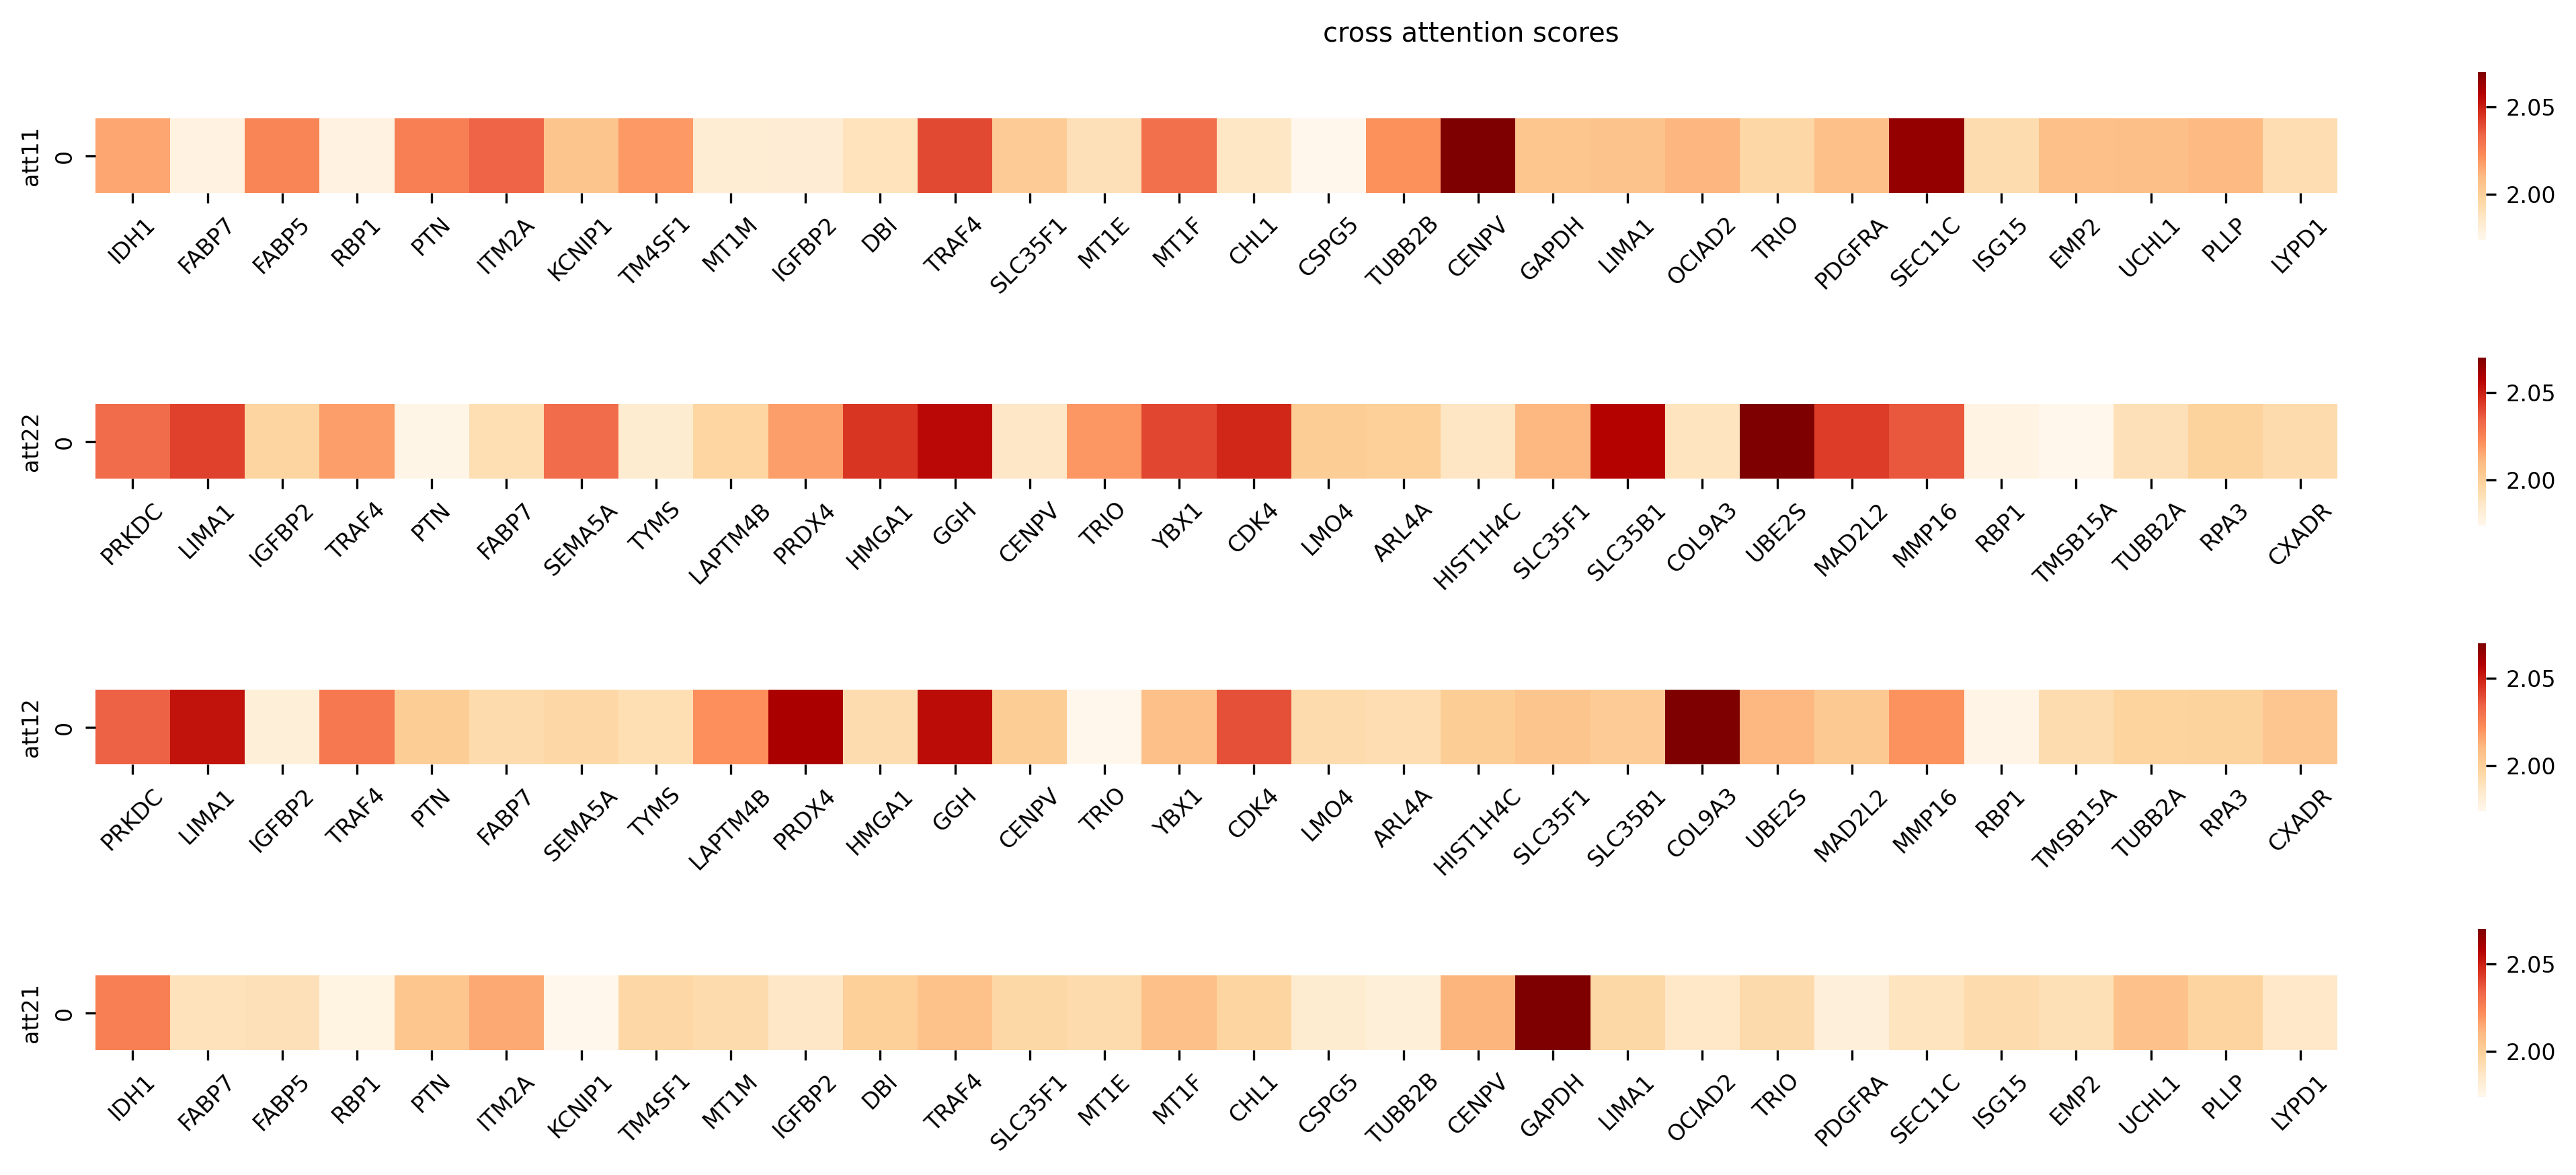

In [112]:
# plot_att_vec(np.vstack(cross_att_vec))
plot_att_vec(cross_att_all)

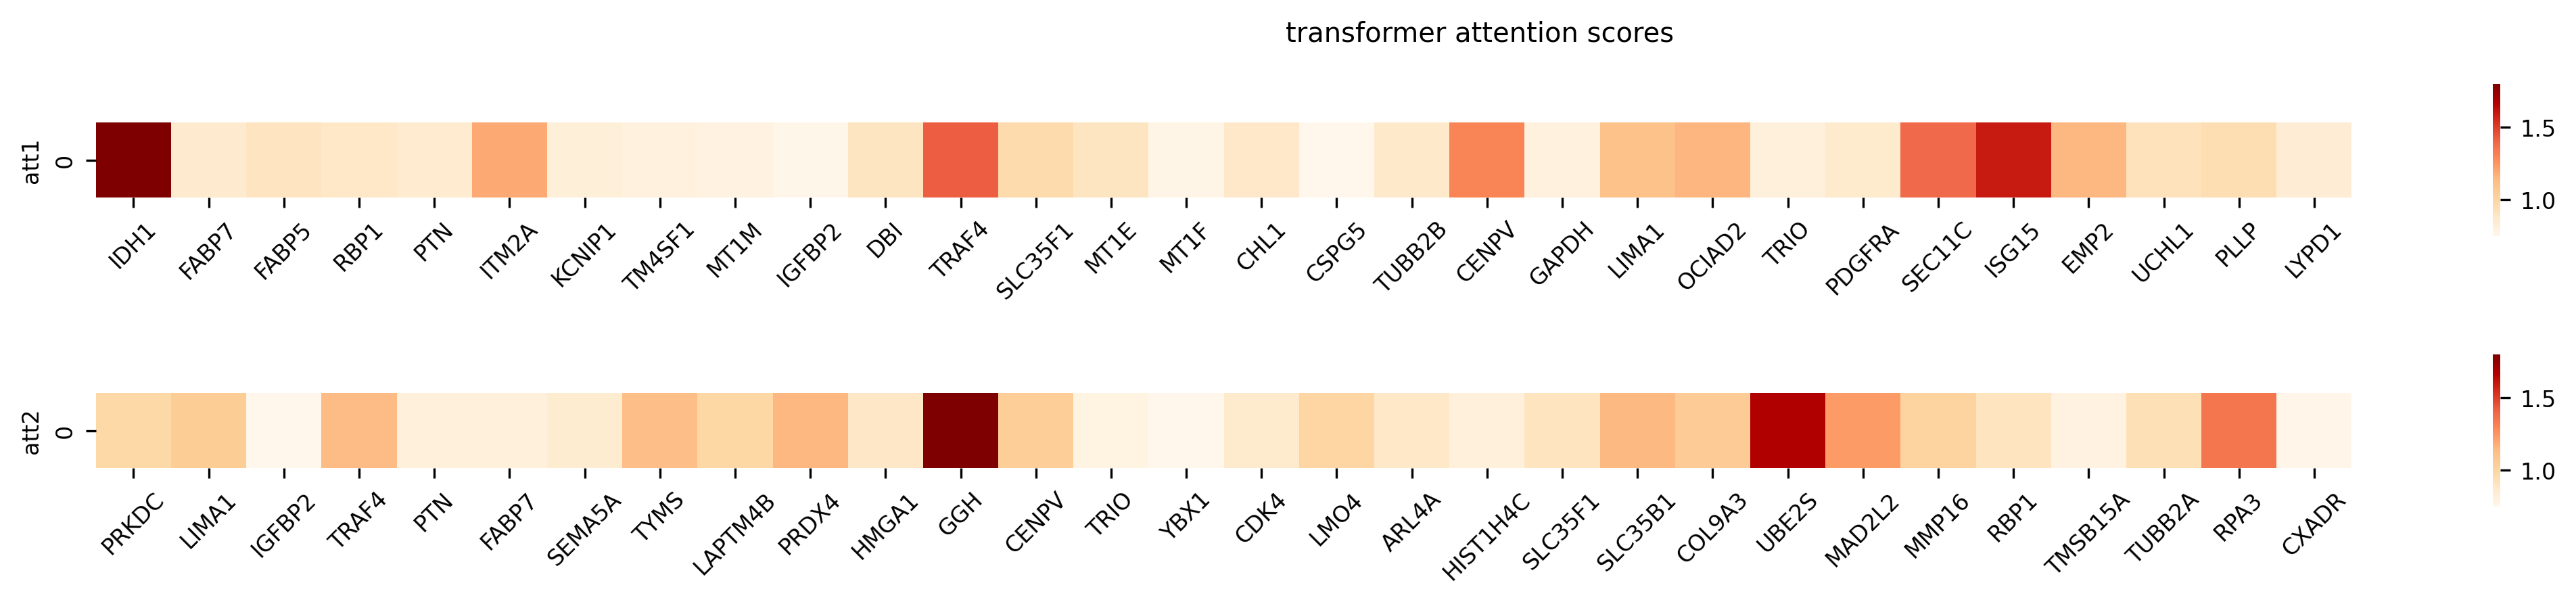

In [113]:
plot_att_vec(trans_att_all)